In [37]:
import pandas as pd

# Path to your Excel file
file_path = 'data/species_866.xlsx'

# Load only the first few rows to read column names
data_scfa = pd.read_excel(file_path, nrows=5, index_col=0)

## differet scfa producers, use different 
# Define your species of interest
scfa_species = ["Bacteroides", "Prevotella", "Coprococcus comes", "Veillonella", "Dialister", "Salmonella","Akkermansia muciniphila", "Bacteroides", "Ruminococcus", "Prevotella", "Escherichia coli", "Fusobacterium",
                "Lactobacillus", "Faecalibacterium prausnitzii", "Roseburia", "Anaerostipes caccae", "Butyrivibrio fibrisolvens", "Subdoligranulum variabile",
                "Anaerotruncus colihominis", "Eubacterium limosum", "Coprococcus"] #"Clostridia"]

# Find columns that contain any of the species names
#filtered_columns = [col for col in data_butyrate.columns if any(species in col for species in butyrate_species)]

filtered_indices = [i for i, col in enumerate(data_scfa.columns, start=1) if any(species in col for species in scfa_species)]

# Include the first column index (0) with the filtered indices
use_columns = [0] + filtered_indices

# Load the entire file with only the filtered columns, setting the first column as the index
scfa_data = pd.read_excel(file_path, usecols=use_columns, index_col=0)


KeyboardInterrupt: 

In [ ]:
columns_to_drop = scfa_data.filter(regex='virus|phage').columns

# Drop these columns from the DataFrame
scfa_data =scfa_data.drop(columns=columns_to_drop)

In [ ]:
scfa_data

In [ ]:
scfa_data.to_excel('data/scfa_species800.xlsx')

In [ ]:
# change to different files scfa, acetate, propinate, butyrate

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
scfa_data = pd.read_excel("data/scfa_species800.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQA862.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

In [4]:
scfa_data = scfa_data.drop(columns=scfa_data.columns[scfa_data.columns.str.contains('sp.')])
scfa_data


,Salmonella bongori,Salmonella enterica,Escherichia coli,Lactobacillus johnsonii,Lactobacillus acidophilus,Lactobacillus delbrueckii,Lactobacillus helveticus,Lactobacillus gasseri,Lactobacillus acetotolerans,Lactobacillus amylovorus,...,Fusobacterium nucleatum,Fusobacterium varium,Fusobacterium necrophorum,Fusobacterium periodonticum,Fusobacterium ulcerans,Fusobacterium pseudoperiodonticum,Fusobacterium hwasookii,Fusobacterium hominis,Fusobacterium gastrosuis,Fusobacterium canifelinum
FREG1_Barcode,,,,,,,,,,,,,,,,,,,,,
10004,0,1893,13352,0,0,54,0,0,0,0,...,0,77,0,0,0,0,0,0,0,0
10005,0,1090,154502,67,0,244,0,0,0,79,...,576,93,0,0,178,123,67,171,0,79
10006,0,440,10357,0,76,17075,0,84,0,142,...,97,0,75,0,59,57,68,0,0,0
10012,0,655,840,0,0,107,0,0,0,0,...,27,0,0,0,31,19,0,0,0,0
10026,0,835,4654,0,0,307,0,0,0,0,...,143,0,91,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PSA-2971-1,0,857,1352,0,0,60,0,0,0,0,...,60,0,0,0,32,0,0,0,0,0
PSA-3006-5,0,982,19647,0,23,33,0,0,0,0,...,24,0,0,0,0,0,0,0,0,0
PSA-3012-3,35,867,173956,36,0,0,0,0,0,0,...,116,0,0,0,0,41,0,0,0,0


In [5]:
print(scfa_data.columns.tolist())

['Salmonella bongori', 'Salmonella enterica', 'Escherichia coli', 'Lactobacillus johnsonii', 'Lactobacillus acidophilus', 'Lactobacillus delbrueckii', 'Lactobacillus helveticus', 'Lactobacillus gasseri', 'Lactobacillus acetotolerans', 'Lactobacillus amylovorus', 'Lactobacillus kefiranofaciens', 'Lactobacillus kullabergensis', 'Lactobacillus helsingborgensis', 'Lactobacillus terrae', 'Lactobacillus apis', 'Lactobacillus paragasseri', 'Lactobacillus jensenii', 'Lactobacillus panisapium', 'Lactobacillus iners', 'Lactobacillus taiwanensis', 'Lactobacillus amylolyticus', 'Lactobacillus intestinalis', 'Lactobacillus ultunensis', '[Ruminococcus] gnavus', '[Ruminococcus] torques', '[Ruminococcus] lactaris', 'Coprococcus eutactus', 'Coprococcus comes', 'Coprococcus catus', 'Butyrivibrio fibrisolvens', 'Roseburia intestinalis', 'Roseburia hominis', 'Anaerostipes caccae', 'Faecalibacterium prausnitzii', 'Ruminococcus albus', 'Ruminococcus bovis', 'Ruminococcus gauvreauii', 'Ruminococcus bicircula

In [6]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [7]:
scfa_data

,Salmonella bongori,Salmonella enterica,Escherichia coli,Lactobacillus johnsonii,Lactobacillus acidophilus,Lactobacillus delbrueckii,Lactobacillus helveticus,Lactobacillus gasseri,Lactobacillus acetotolerans,Lactobacillus amylovorus,...,Fusobacterium nucleatum,Fusobacterium varium,Fusobacterium necrophorum,Fusobacterium periodonticum,Fusobacterium ulcerans,Fusobacterium pseudoperiodonticum,Fusobacterium hwasookii,Fusobacterium hominis,Fusobacterium gastrosuis,Fusobacterium canifelinum
10004,0,1893,13352,0,0,54,0,0,0,0,...,0,77,0,0,0,0,0,0,0,0
10005,0,1090,154502,67,0,244,0,0,0,79,...,576,93,0,0,178,123,67,171,0,79
10006,0,440,10357,0,76,17075,0,84,0,142,...,97,0,75,0,59,57,68,0,0,0
10012,0,655,840,0,0,107,0,0,0,0,...,27,0,0,0,31,19,0,0,0,0
10026,0,835,4654,0,0,307,0,0,0,0,...,143,0,91,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PSA-2971-1,0,857,1352,0,0,60,0,0,0,0,...,60,0,0,0,32,0,0,0,0,0
PSA-3006-5,0,982,19647,0,23,33,0,0,0,0,...,24,0,0,0,0,0,0,0,0,0
PSA-3012-3,35,867,173956,36,0,0,0,0,0,0,...,116,0,0,0,0,41,0,0,0,0
PSA-3030-5,0,170,5324,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [9]:


def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender','BMI']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender','BMI']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])




In [10]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [11]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


In [48]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 5
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]


In [49]:
filtered_species_scfa.index

Index(['Lactobacillus acidophilus', 'Lactobacillus delbrueckii',
       'Lactobacillus acetotolerans', 'Lactobacillus amylovorus',
       'Lactobacillus helsingborgensis', 'Lactobacillus terrae',
       'Lactobacillus apis', 'Lactobacillus jensenii', 'Lactobacillus iners',
       'Lactobacillus taiwanensis', 'Lactobacillus amylolyticus',
       'Lactobacillus intestinalis', 'Veillonella nakazawae',
       'Veillonella rogosae', 'Bacteroides thetaiotaomicron',
       'Bacteroides intestinalis', 'Bacteroides cellulosilyticus',
       'Akkermansia muciniphila', 'Fusobacterium mortiferum',
       'Fusobacterium periodonticum', 'Fusobacterium ulcerans'],
      dtype='object')

In [50]:
## drop phage and virus

<Figure size 1440x1440 with 0 Axes>

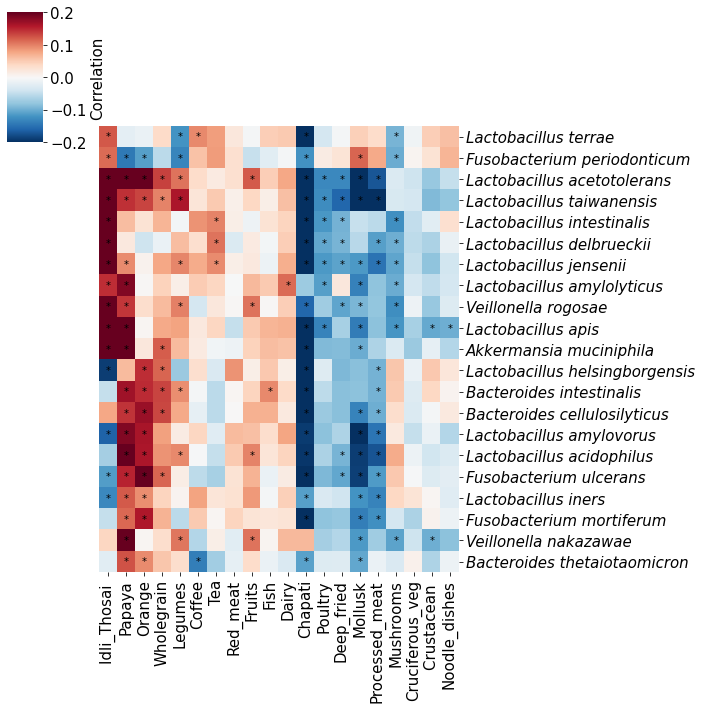

In [51]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)


plt.figure(figsize=(20, 20))
ax = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

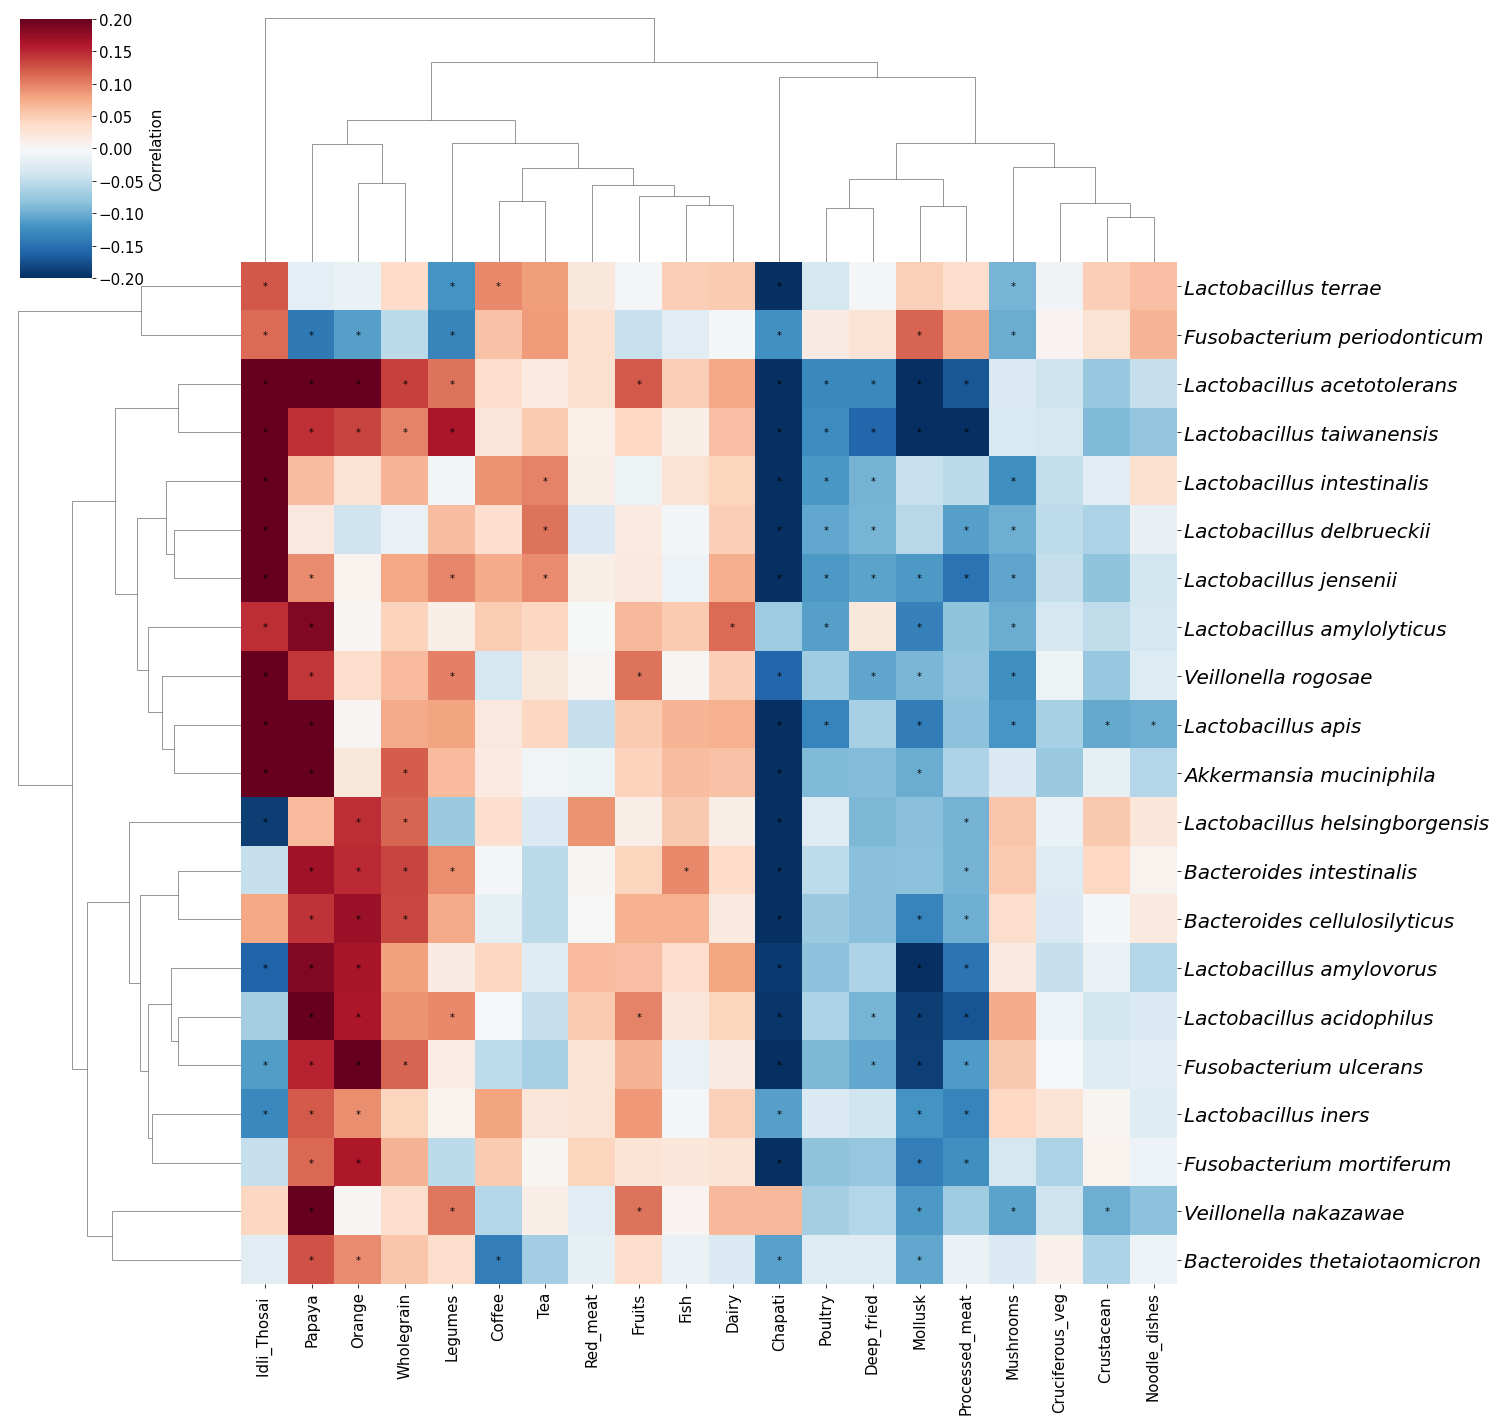

In [53]:


# Assuming filtered_species_scfa, significant_matrix_scfa are defined as per your context
# Clipping values
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20)  # Adjust size directly here if needed
)

# Making dendrograms visible to check the layout
ax.ax_row_dendrogram.set_visible(True)
ax.ax_col_dendrogram.set_visible(True)

# Get the order of rows and columns after clustering
row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})
#fig = plt.gcf()
#fig.set_size_inches(12, 22)
#plt.savefig('figure/food_scfa_cluster800_less.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


Index(['Fish', 'Crustacean ', 'Mollusk', 'Poultry', 'Red_meat',
       'Processed_meat', 'Dairy', 'Cruciferous_veg', 'Legumes', 'Mushrooms',
       'Fruits', 'Papaya', 'Orange', 'Wholegrain', 'Chapati', 'Idli_Thosai ',
       'Noodle_dishes', 'Deep_fried', 'Coffee', 'Tea'],
      dtype='object')

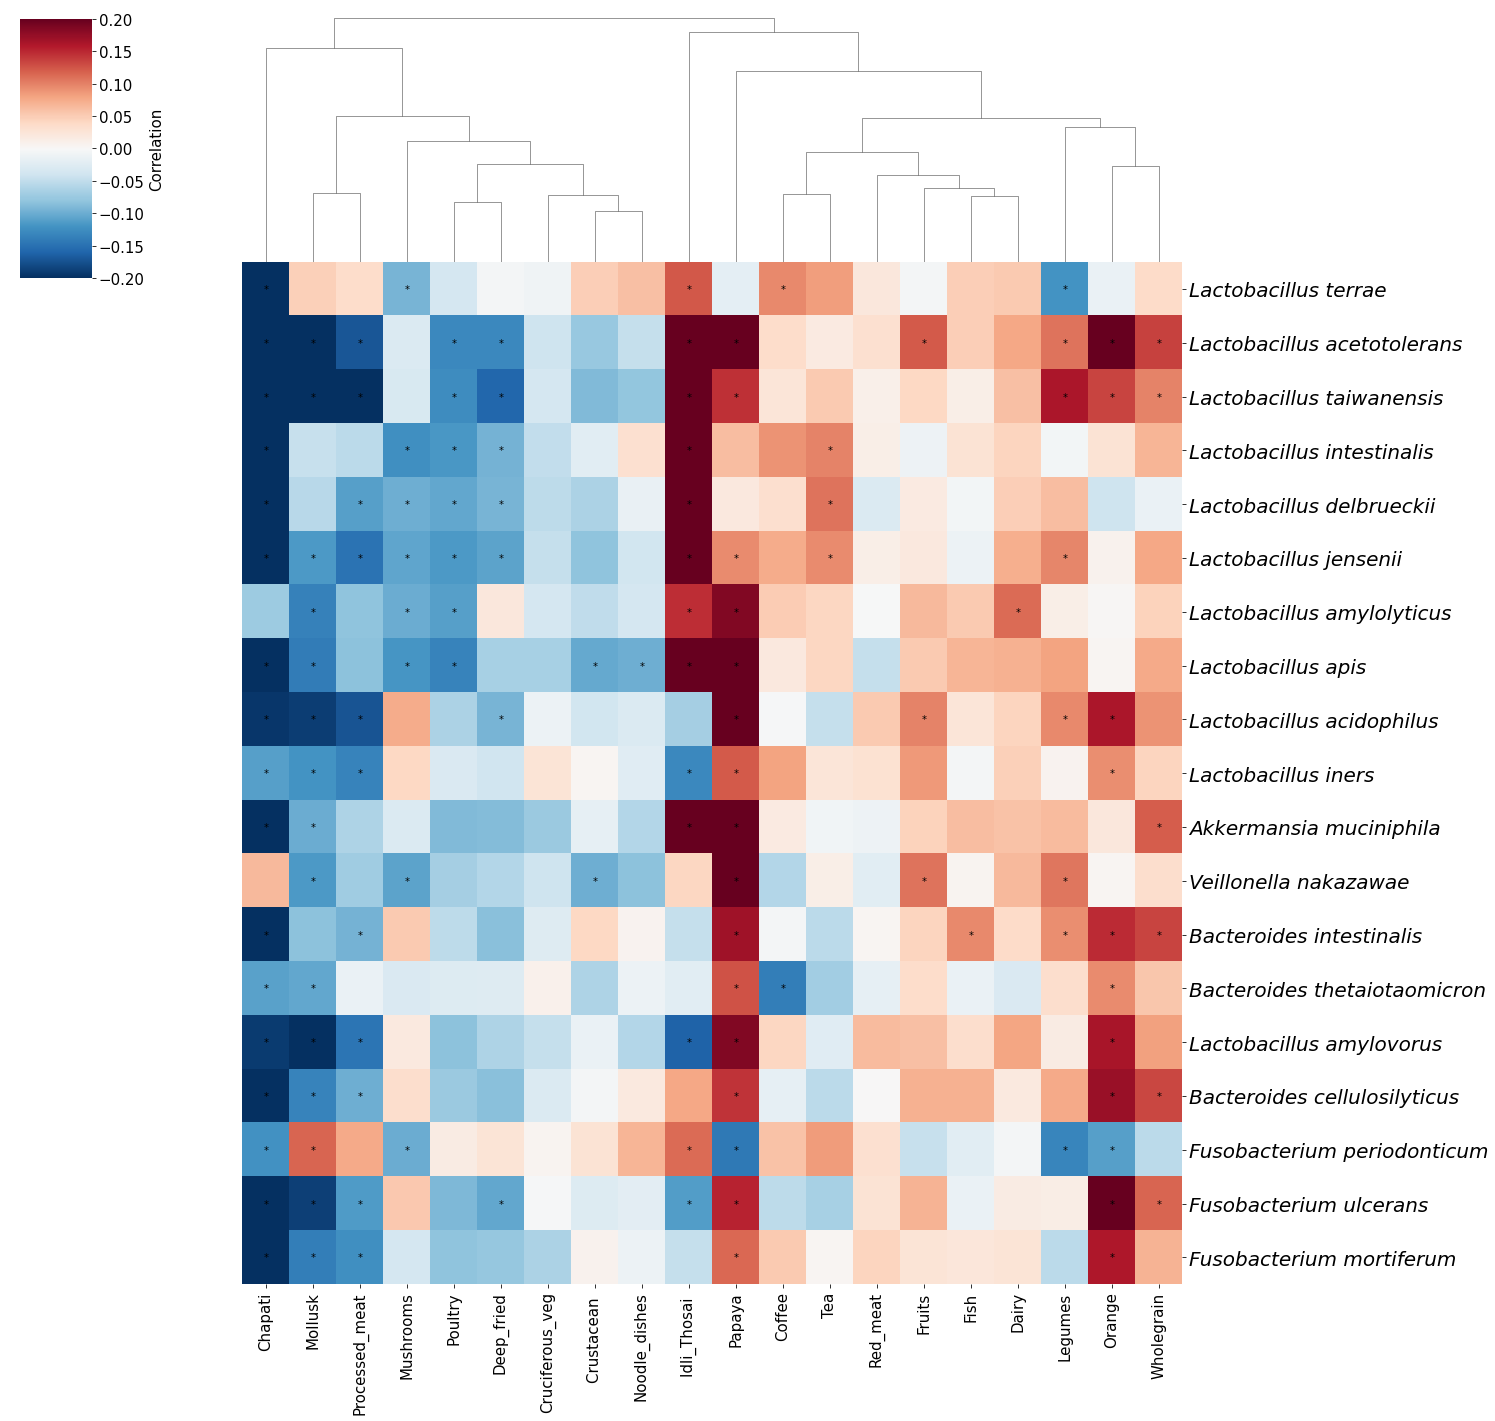

In [58]:

row_order = [ "Lactobacillus terrae", "Lactobacillus acetotolerans", "Lactobacillus taiwanensis", 
        "Lactobacillus intestinalis", "Lactobacillus delbrueckii", "Lactobacillus jensenii", 
        "Lactobacillus amylolyticus", "Lactobacillus apis", "Lactobacillus acidophilus", 
        "Lactobacillus iners", "Akkermansia muciniphila","Veillonella nakazawae", "Bacteroides intestinalis", 
        "Bacteroides thetaiotaomicron", "Lactobacillus amylovorus", "Bacteroides cellulosilyticus", 
        "Fusobacterium periodonticum", "Fusobacterium ulcerans", "Fusobacterium mortiferum"]
filtered_species_scfa = filtered_species_scfa.loc[row_order]

filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]


clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

#plt.savefig('figure/spe_scfa_ordered_heatmap800.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [57]:
#ordered_indices = ax.dendrogram_row.reordered_ind

# Print the ordered row names
#ordered_row_names = clipped_correlations_scfa.index[ordered_indices]
#print(ordered_row_names)
food_row_order = ax.dendrogram_row.reordered_ind

AttributeError: 'NoneType' object has no attribute 'reordered_ind'

In [67]:
#nutrition

In [58]:

scfa_data = pd.read_excel("data/scfa_species800.xlsx", index_col=0)
food_data_spear = pd.read_excel('data/FFQB800.xlsx', index_col=0)
participants_data = pd.read_excel('data/ethnicity_866.xlsx', index_col=0)

In [59]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [60]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [61]:
def adjust_for_covariates(data, covariates, categorical_vars=[]):
    # Generate dummy variables for categorical variables
    if categorical_vars:
        covariates = pd.get_dummies(covariates, columns=categorical_vars, drop_first=True)
    
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid

    return adjusted_data

# Adjust microbiome and diet data
# Ensure that 'FREG5_Ethnic_Group' is included as a categorical variable
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender','BMI']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['FREG8_Age', 'FREG5_Ethnic_Group','FREG7_Gender','BMI']], categorical_vars=['FREG5_Ethnic_Group','FREG7_Gender'])




In [62]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [63]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


In [65]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 0
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]
##significant_species

##filtered_species_scfa = filtered_species_scfa.iloc[food_row_order, :]
filtered_species_scfa

,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,fibre,VitaminA,VitaminC,Calcium,Iron,Bcarotene,Thiamin,Riboflavin,Potassium,Zinc
Salmonella sp. 14,0.010301,0.004282,0.007422,0.016461,-0.000914,-0.007694,-0.004987,-0.006364,-0.012543,0.003183,-0.011220,0.005595,-0.009157,-0.008533,0.024229,-0.003165,-0.002027,0.004832,0.008898
Salmonella sp.,-0.042345,-0.027500,-0.035256,-0.046154,-0.026874,-0.020689,-0.028801,-0.017786,-0.033667,-0.034689,-0.008154,-0.027716,-0.014426,-0.028157,-0.024392,-0.022610,-0.023816,-0.032717,-0.030370
Salmonella sp. SCFS4,-0.013687,-0.006753,-0.012617,-0.020014,-0.014661,-0.009388,-0.019679,-0.010617,-0.031473,0.001834,-0.013874,0.002112,-0.028189,-0.004517,0.021234,-0.009451,-0.011617,0.003093,-0.015989
Salmonella sp. 2018103,0.010385,0.016824,0.014117,0.010209,0.022621,0.022689,0.015276,0.016347,0.013673,0.010229,0.025786,0.003376,0.001522,0.030506,-0.025167,0.008571,0.014126,0.005171,0.018735
Salmonella sp. SSDFZ54,-0.002349,-0.006062,-0.007095,-0.001671,-0.008954,-0.009423,0.000347,-0.009844,0.006557,-0.012339,0.000868,-0.017395,0.023809,-0.017375,-0.020941,0.019424,0.004736,-0.010548,-0.001249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fusobacterium hominis,-0.000294,0.001350,0.007650,0.009066,0.003449,0.010522,-0.013846,-0.033953,0.040956,-0.002979,-0.007746,0.009634,0.015584,-0.000515,0.015402,0.010330,0.011319,0.008931,-0.000449
Fusobacterium gastrosuis,0.023778,0.023994,0.030296,0.032481,0.033608,0.018047,0.017432,0.002731,0.026761,0.012657,0.018952,0.018706,0.012525,0.027087,-0.032303,0.018740,0.026894,0.002249,0.033707
Fusobacterium canifelinum,-0.011687,0.001169,0.004234,0.016763,0.003148,-0.009942,-0.031820,-0.047176,-0.013046,-0.020509,-0.012689,-0.005082,-0.004594,-0.002816,-0.048401,-0.012003,0.003141,-0.026833,-0.002184
Fusobacterium sp. oral taxon 203,-0.002555,0.001469,0.009279,0.014789,0.014377,-0.003272,-0.013994,-0.017634,-0.027745,-0.018294,-0.014279,-0.012571,-0.040205,-0.007172,-0.054969,-0.018455,-0.014026,-0.026591,0.007410


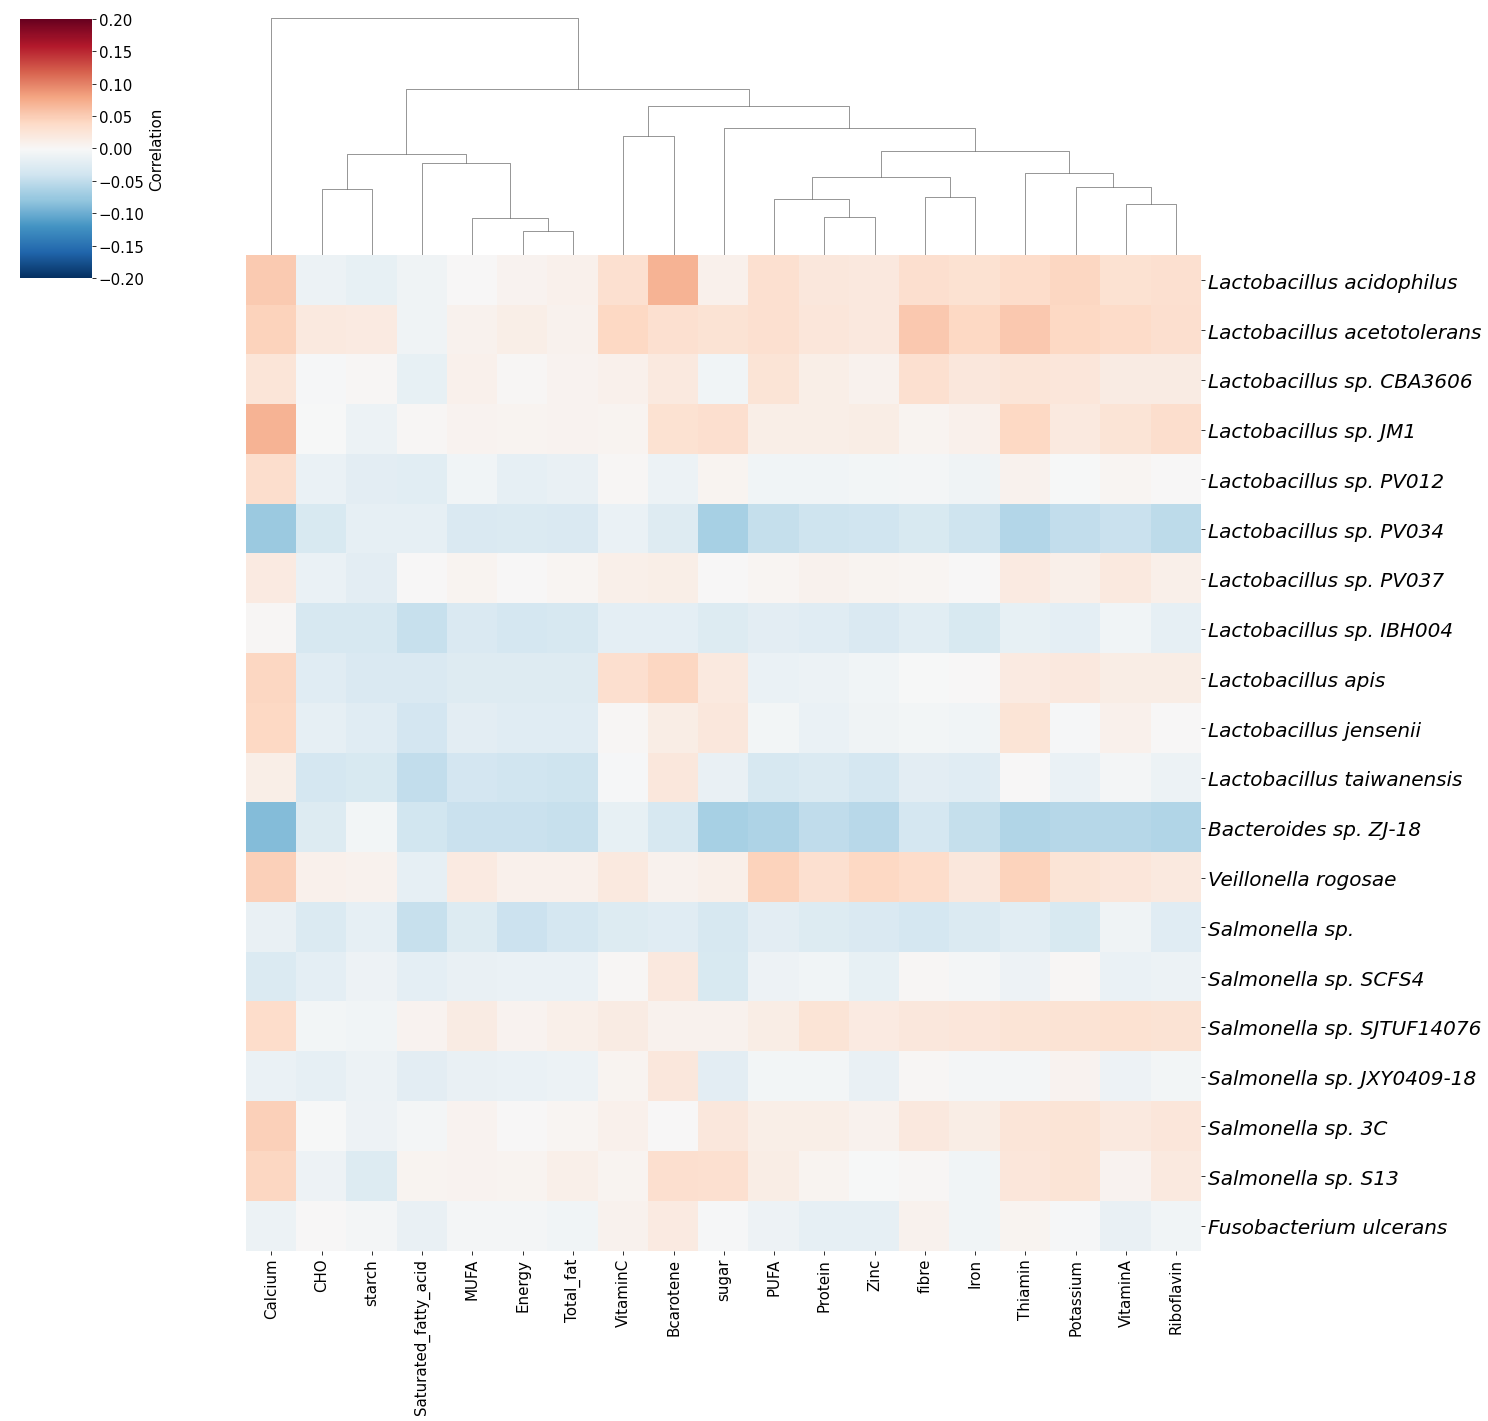

In [67]:
filtered_species_scfa = filtered_species_scfa.loc[row_order]
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]


clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

#plt.savefig('figure/nutrition_scfa_ordered_heatmap800.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

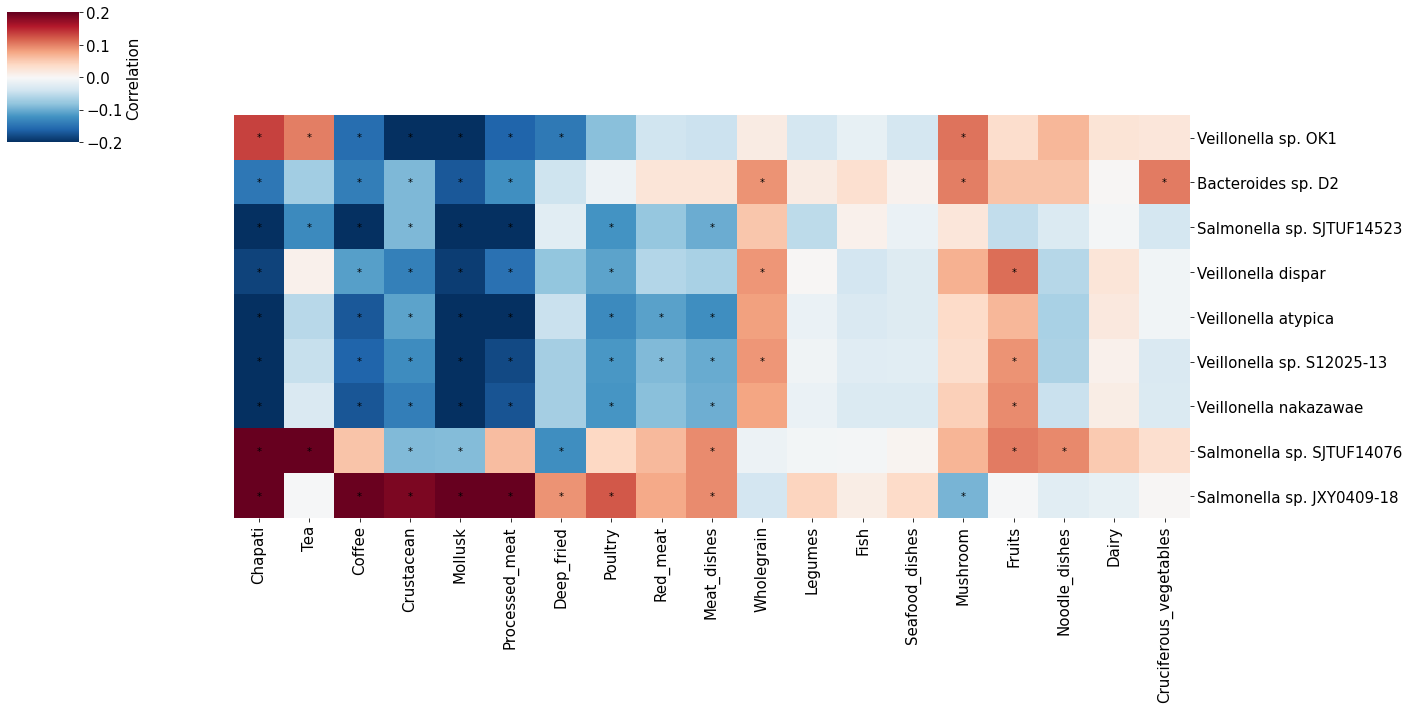

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(20, 10))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)


# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

plt.show()


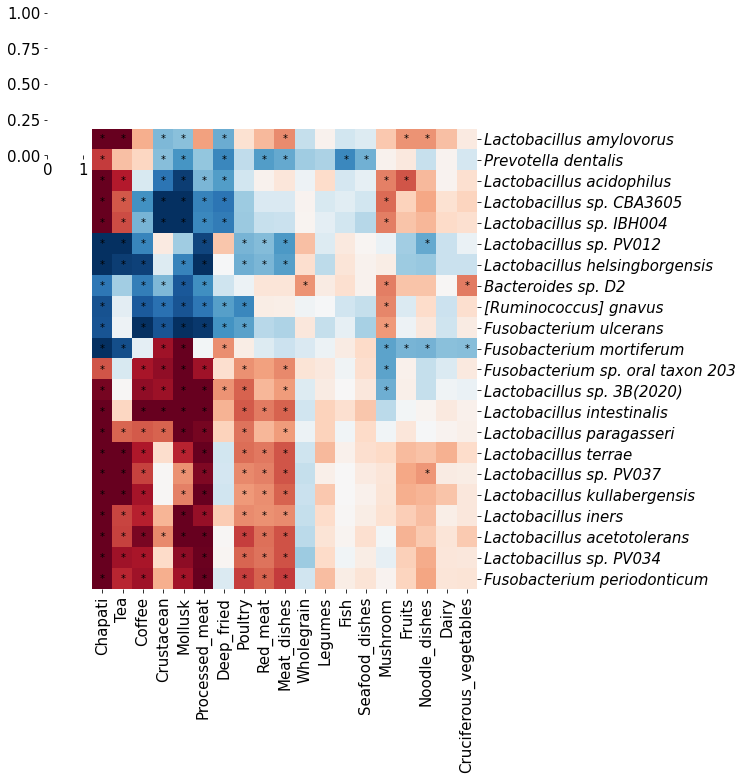

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only, no color bar, trying to make it more square-like
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar=False, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(10, 11), dendrogram_ratio=(.1, .2))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)

# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in cluster_grid.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
cluster_grid.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.show()


In [ ]:
## not just for scfa